    N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB
None
label
ric

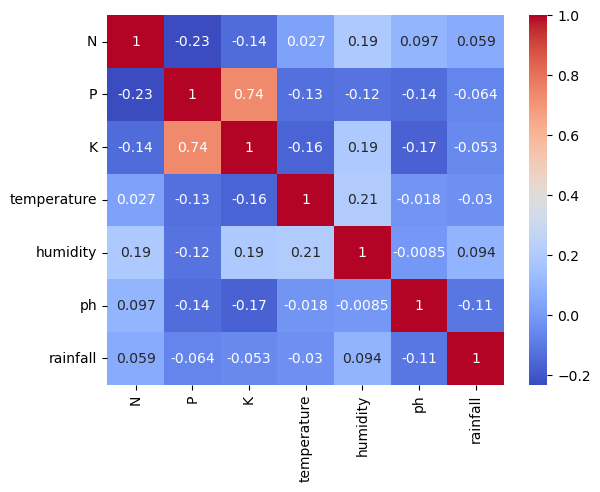

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Crop_recommendation.csv')
print(df.head())
print(df.info())
print(df['label'].value_counts())  # kitne crops hain

sns.heatmap(df.drop('label', axis=1).corr(), annot=True, cmap='coolwarm')
plt.show()

In [20]:
import pandas as pd
import numpy as np

df = pd.read_csv('Crop_recommendation.csv')

# Naye crops add karo
def generate_samples(n, N, P, K, temp, humidity, ph, rainfall, label):
    return pd.DataFrame({
        'N':           np.random.randint(N-10, N+10, n),
        'P':           np.random.randint(P-10, P+10, n),
        'K':           np.random.randint(K-10, K+10, n),
        'temperature': np.random.uniform(temp-2, temp+2, n),
        'humidity':    np.random.uniform(humidity-5, humidity+5, n),
        'ph':          np.random.uniform(ph-0.3, ph+0.3, n),
        'rainfall':    np.random.uniform(rainfall-15, rainfall+15, n),
        'label':       label
    })

new_crops = pd.concat([
    generate_samples(100, 60, 40, 20, 15.0, 55.0, 6.5, 70.0,  'wheat'),
    generate_samples(100, 40, 25, 15, 28.0, 50.0, 7.2, 55.0,  'bajra'),
    generate_samples(100, 25, 50, 30, 27.0, 65.0, 6.2, 95.0,  'groundnut'),
    generate_samples(100, 35, 60, 40, 25.0, 68.0, 6.8, 110.0, 'soybean'),
    generate_samples(100, 80, 40, 50, 30.0, 80.0, 6.5, 180.0, 'sugarcane'),
    generate_samples(100, 30, 20, 15, 27.0, 48.0, 7.0, 50.0,  'jowar'),
    generate_samples(100, 50, 30, 10, 18.0, 58.0, 6.8, 60.0,  'mustard'),
])

df = pd.concat([df, new_crops], ignore_index=True)
print(f"Total crops: {df['label'].nunique()}")
print(f"Total rows: {len(df)}")

Total crops: 29
Total rows: 2900


In [21]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

X = df.drop('label', axis=1)
y = df['label']

le = LabelEncoder()
y = le.fit_transform(y)  # crop names → numbers

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [22]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [23]:
from sklearn.metrics import accuracy_score, classification_report

for name, model in [("Random Forest", rf)]:
    pred = model.predict(X_test)
    print(f"\n{name} Accuracy: {accuracy_score(y_test, pred):.4f}")
    print(classification_report(y_test, pred, target_names=le.classes_))


Random Forest Accuracy: 0.9862
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        17
       bajra       0.95      0.86      0.90        21
      banana       1.00      1.00      1.00        24
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        23
     coconut       1.00      1.00      1.00        18
      coffee       1.00      1.00      1.00        18
      cotton       1.00      1.00      1.00        17
      grapes       1.00      1.00      1.00        24
   groundnut       0.91      1.00      0.95        21
       jowar       0.88      0.96      0.92        23
        jute       0.96      1.00      0.98        25
 kidneybeans       1.00      1.00      1.00        17
      lentil       1.00      1.00      1.00        19
       maize       1.00      1.00      1.00        22
       mango       1.00      1.00      1.00        15
   mothbeans       1.00      1.00      1.00      

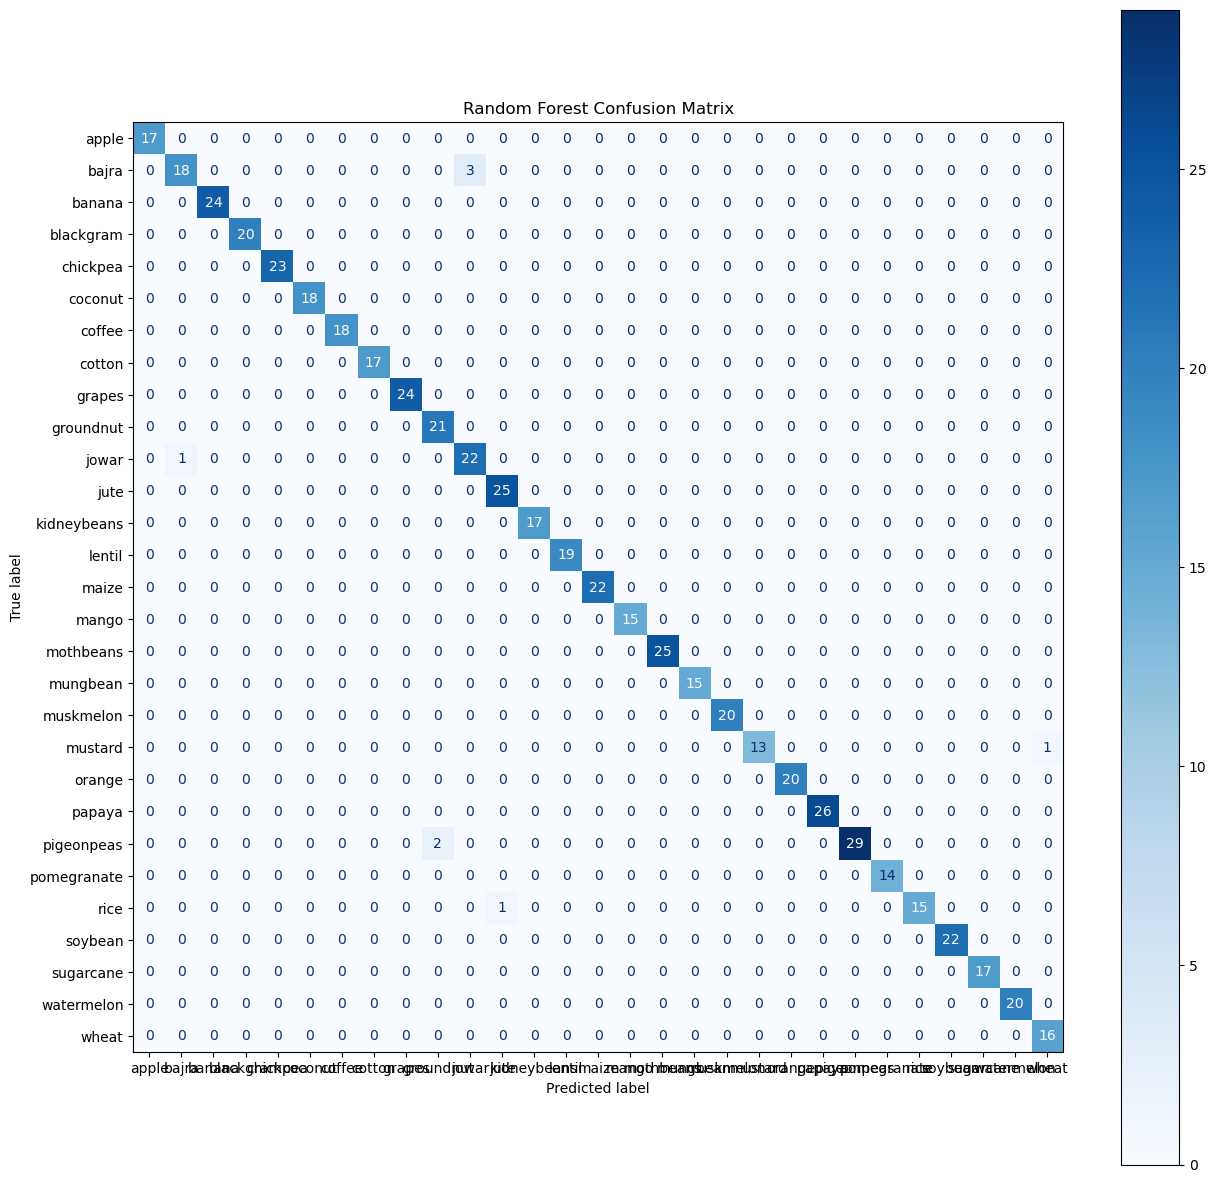

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf.predict(X_test))
fig, ax = plt.subplots(figsize=(15,15))
disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
disp.plot(ax=ax, cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.show()

In [25]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(rf, X_scaled, y, cv=5)
print(f"CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

CV Accuracy: 0.9838 ± 0.0039


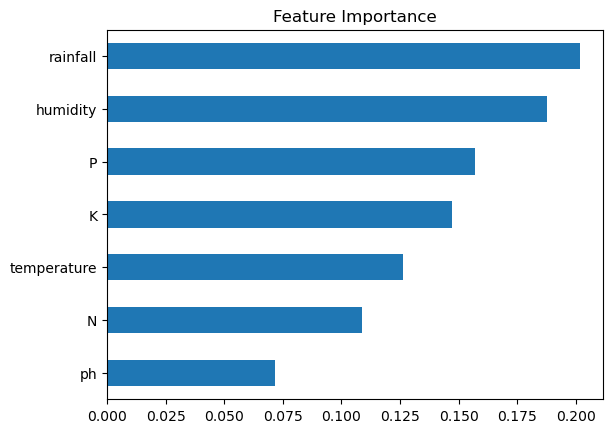

In [26]:
feat_imp = pd.Series(rf.feature_importances_, index=df.drop('label',axis=1).columns)
feat_imp.sort_values().plot(kind='barh', title='Feature Importance')
plt.show()

In [27]:
# manually banao ek fake farmer input
sample = pd.DataFrame([[90, 42, 43, 20.8, 82.0, 6.5, 202.9]],
                       columns=['N','P','K','temperature','humidity','ph','rainfall'])

sample_scaled = scaler.transform(sample)
pred = rf.predict(sample_scaled)
prob = rf.predict_proba(sample_scaled)

print(f"Recommended Crop: {le.inverse_transform(pred)[0]}")
print(f"Confidence: {prob.max()*100:.2f}%")

Recommended Crop: rice
Confidence: 98.00%


In [28]:
top3_idx = prob[0].argsort()[-3:][::-1]
for i in top3_idx:
    print(f"{le.classes_[i]}: {prob[0][i]*100:.2f}%")

rice: 98.00%
jute: 2.00%
wheat: 0.00%


In [29]:
import pickle

with open('crop_model.pkl', 'wb') as f:
    pickle.dump(rf, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)
    

In [30]:
import os
print(os.getcwd()) 

C:\Users\ASUS\AI_Crop_predictor


In [31]:
from sklearn.model_selection import cross_val_score

cv = cross_val_score(rf, X_scaled, y, cv=5)
print(f"CV Scores: {cv}")
print(f"CV Mean:   {cv.mean()*100:.2f}%")
print(f"CV Std:    {cv.std()*100:.2f}%")

CV Scores: [0.98275862 0.98275862 0.98793103 0.98793103 0.97758621]
CV Mean:   98.38%
CV Std:    0.39%


In [32]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import pandas as pd

svm = SVC(kernel='rbf', probability=True, random_state=42)
svm.fit(X_train, y_train)

results = pd.DataFrame({
    'Model': ['Random Forest', 'SVM (RBF)'],
    'Train Accuracy': [
        accuracy_score(y_train, rf.predict(X_train))*100,
        accuracy_score(y_train, svm.predict(X_train))*100
    ],
    'Test Accuracy': [
        accuracy_score(y_test, rf.predict(X_test))*100,
        accuracy_score(y_test, svm.predict(X_test))*100
    ]
})
print(results.round(2))


           Model  Train Accuracy  Test Accuracy
0  Random Forest          100.00          98.62
1      SVM (RBF)           97.63          96.90


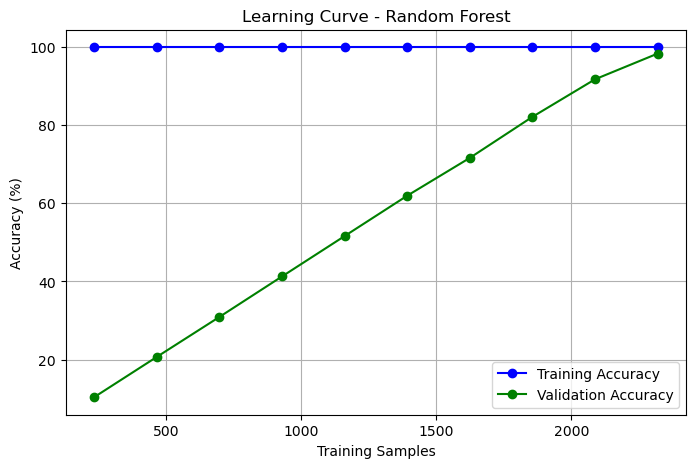

In [33]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, val_scores = learning_curve(
    rf, X_scaled, y, cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy'
)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_scores.mean(axis=1)*100, 
         'o-', color='blue', label='Training Accuracy')
plt.plot(train_sizes, val_scores.mean(axis=1)*100, 
         'o-', color='green', label='Validation Accuracy')
plt.title('Learning Curve - Random Forest')
plt.xlabel('Training Samples')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.show()

In [34]:
print(f"Total crops in model: {len(le.classes_)}")
print(le.classes_)

Total crops in model: 29
['apple' 'bajra' 'banana' 'blackgram' 'chickpea' 'coconut' 'coffee'
 'cotton' 'grapes' 'groundnut' 'jowar' 'jute' 'kidneybeans' 'lentil'
 'maize' 'mango' 'mothbeans' 'mungbean' 'muskmelon' 'mustard' 'orange'
 'papaya' 'pigeonpeas' 'pomegranate' 'rice' 'soybean' 'sugarcane'
 'watermelon' 'wheat']


In [35]:
print(df.shape)
print(df['label'].nunique())

(2900, 8)
29
